### Libraries

In [167]:
import pandas as pd
import numpy as np

# Others
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Model Development Core Libs
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Scaling, Onehot Encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

#Standard Linear Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error

#RF Model
from sklearn.ensemble import RandomForestRegressor

#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit



### Reading in the data

In [168]:
working_directory = Path.cwd().parent.parent
print(working_directory)
hist_driver_points_price = working_directory / "data" / "semi-clean" / "hist_driver_points_df_v1.csv"
curr_week_driver_points_price = working_directory / "data" / "semi-clean" / "current_week_driver_points_df_v1.csv"

/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject


In [169]:
hist = pd.read_csv(hist_driver_points_price).drop(columns=["Unnamed: 0"])
hist.head()

,year,race_num,race_name,location,start_date,driver,price,points,constructor,country_code,month,start_epoch,price_change_prev_race,price_rank,points_last_three_avg,points_last_five_avg,ppm_last_3,ppm_last_5
0,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,VER,26.9,35.0,RBR,BRN,3,1678028400,NaN,1.0,NaN,NaN,NaN,NaN
1,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,HAM,23.7,19.0,MER,BRN,3,1678028400,NaN,2.0,NaN,NaN,NaN,NaN
2,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,LEC,21.2,-11.0,FER,BRN,3,1678028400,NaN,3.0,NaN,NaN,NaN,NaN
3,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,RUS,18.6,16.0,MER,BRN,3,1678028400,NaN,4.0,NaN,NaN,NaN,NaN
4,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,PER,18.0,28.0,RBR,BRN,3,1678028400,NaN,5.0,NaN,NaN,NaN,NaN


In [170]:
curr = pd.read_csv(curr_week_driver_points_price).drop(columns=["Unnamed: 0"])
curr.head()

,year,race_num,race_name,location,start_date,driver,price,points,constructor,country_code,month,start_epoch,price_change_prev_race,price_rank,points_last_three_avg,points_last_five_avg,ppm_last_3,ppm_last_5
0,2026,1,Australian Grand Prix,Melbourne,2026-03-08 04:00:00+00:00,VER,27.7,NaN,RBR,AUS,3,1772942400,-2.4,1.0,52.33,49.2,1.89,1.78
1,2026,1,Australian Grand Prix,Melbourne,2026-03-08 04:00:00+00:00,RUS,27.4,NaN,MER,AUS,3,1772942400,3.7,2.0,24.00,25.2,0.88,0.92
2,2026,1,Australian Grand Prix,Melbourne,2026-03-08 04:00:00+00:00,NOR,27.2,NaN,MCL,AUS,3,1772942400,-3.1,3.0,14.67,25.8,0.54,0.95
3,2026,1,Australian Grand Prix,Melbourne,2026-03-08 04:00:00+00:00,PIA,25.5,NaN,MCL,AUS,3,1772942400,0.4,4.0,20.00,16.8,0.78,0.66
4,2026,1,Australian Grand Prix,Melbourne,2026-03-08 04:00:00+00:00,ANT,23.2,NaN,MER,AUS,3,1772942400,5.1,5.0,20.00,24.0,0.86,1.03


## Data Cleaning and Quality Checks

In [171]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1399 non-null   int64  
 1   race_num                1399 non-null   int64  
 2   race_name               1399 non-null   object 
 3   location                1399 non-null   object 
 4   start_date              1399 non-null   object 
 5   driver                  1399 non-null   object 
 6   price                   1399 non-null   float64
 7   points                  1399 non-null   float64
 8   constructor             1398 non-null   object 
 9   country_code            1399 non-null   object 
 10  month                   1399 non-null   int64  
 11  start_epoch             1399 non-null   int64  
 12  price_change_prev_race  1313 non-null   float64
 13  price_rank              1399 non-null   float64
 14  points_last_three_avg   1366 non-null   

Constructor
- not quite sure why this got brought forth as it should have been cleaned out in driverLevelDataClean, but i will filter it out again

price_change_prev_race (should be the first race rows of 2023, and when there is a substitute for a driver that didnt drive in the last race

Running Averages
- will probably only keep the records that dont have missing values for these running averages a. the non-null count is quite high

In [172]:
hist = hist[~hist["constructor"].isna()]

#### Removing all rows if there is an NAN in hist

In [173]:
hist = hist.dropna()

In [174]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1313 entries, 20 to 1398
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1313 non-null   int64  
 1   race_num                1313 non-null   int64  
 2   race_name               1313 non-null   object 
 3   location                1313 non-null   object 
 4   start_date              1313 non-null   object 
 5   driver                  1313 non-null   object 
 6   price                   1313 non-null   float64
 7   points                  1313 non-null   float64
 8   constructor             1313 non-null   object 
 9   country_code            1313 non-null   object 
 10  month                   1313 non-null   int64  
 11  start_epoch             1313 non-null   int64  
 12  price_change_prev_race  1313 non-null   float64
 13  price_rank              1313 non-null   float64
 14  points_last_three_avg   1313 non-null   floa

#### early drops 
- start date because it is redundent and model cant use datetimes

In [175]:
hist = hist.drop(columns =["start_date"])
curr = curr.drop(columns =["start_date"])

In [176]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1313 entries, 20 to 1398
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1313 non-null   int64  
 1   race_num                1313 non-null   int64  
 2   race_name               1313 non-null   object 
 3   location                1313 non-null   object 
 4   driver                  1313 non-null   object 
 5   price                   1313 non-null   float64
 6   points                  1313 non-null   float64
 7   constructor             1313 non-null   object 
 8   country_code            1313 non-null   object 
 9   month                   1313 non-null   int64  
 10  start_epoch             1313 non-null   int64  
 11  price_change_prev_race  1313 non-null   float64
 12  price_rank              1313 non-null   float64
 13  points_last_three_avg   1313 non-null   float64
 14  points_last_five_avg    1313 non-null   floa

### Outliers

In [177]:
hist.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'points', 'constructor', 'country_code', 'month', 'start_epoch',
       'price_change_prev_race', 'price_rank', 'points_last_three_avg',
       'points_last_five_avg', 'ppm_last_3', 'ppm_last_5'],
      dtype='object')

In [178]:
numeric_types = ['year', 'race_num', 'price', 'points', "month", 'start_epoch', 
                 'price_change_prev_race', 'price_rank', 'points_last_three_avg', 'points_last_five_avg', 
                 'ppm_last_3', 'ppm_last_5']

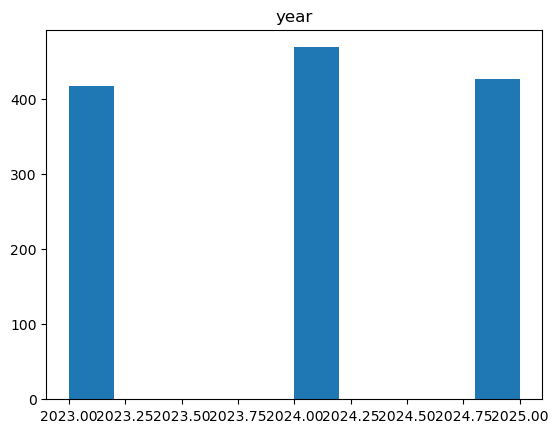

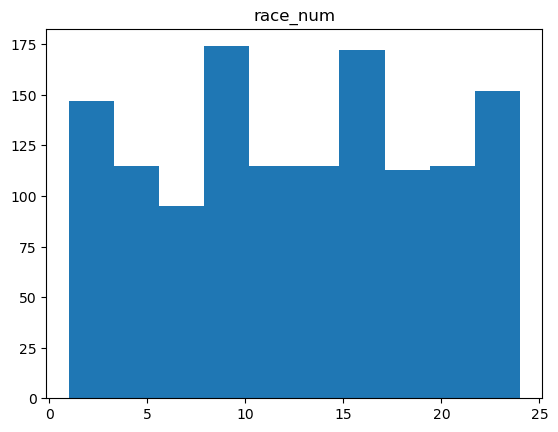

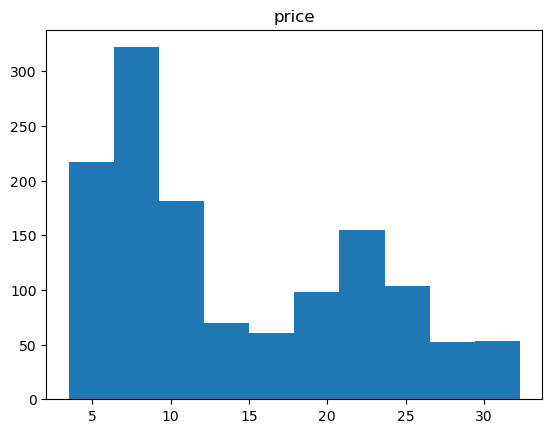

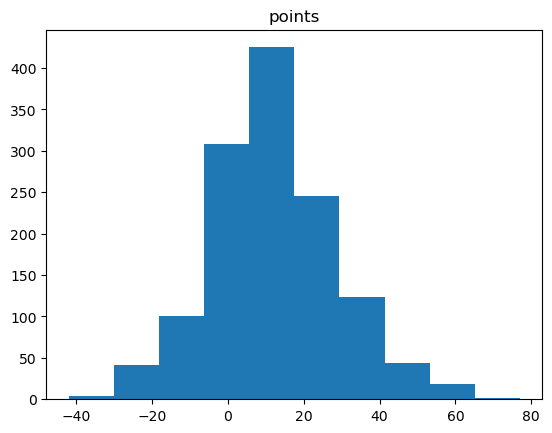

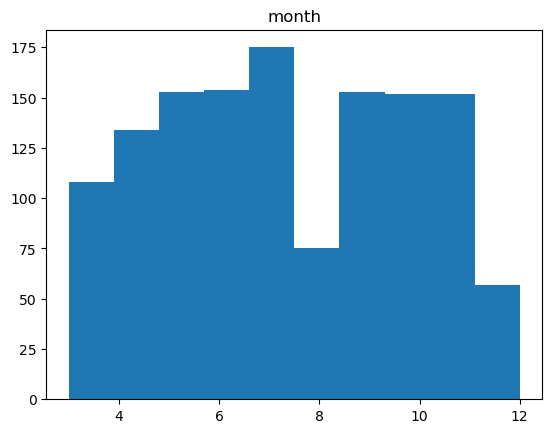

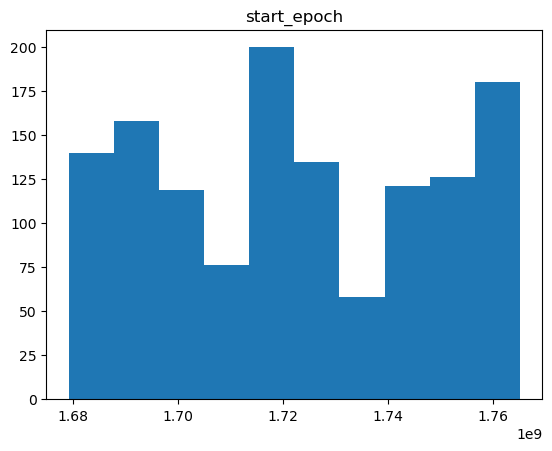

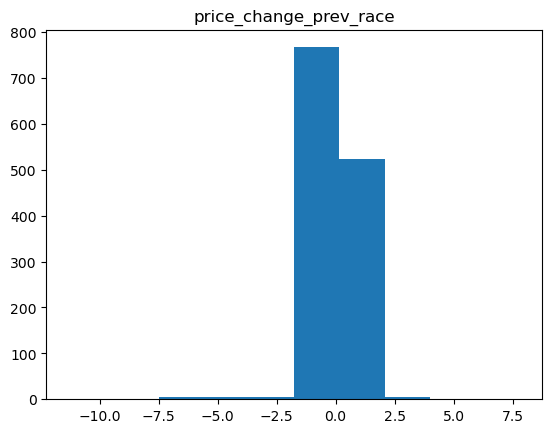

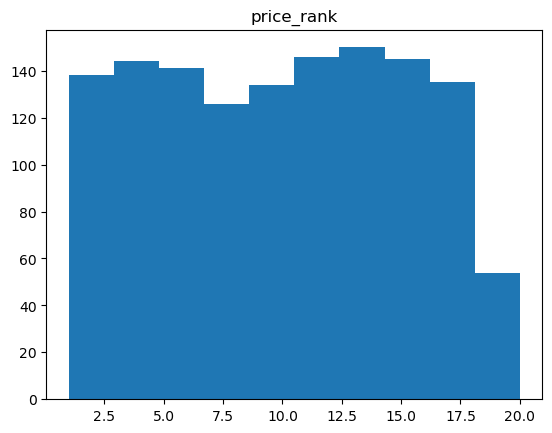

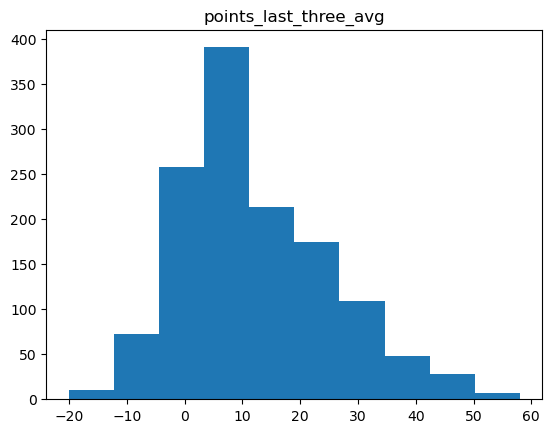

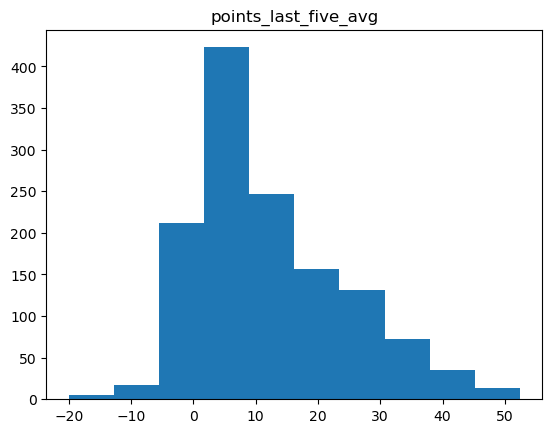

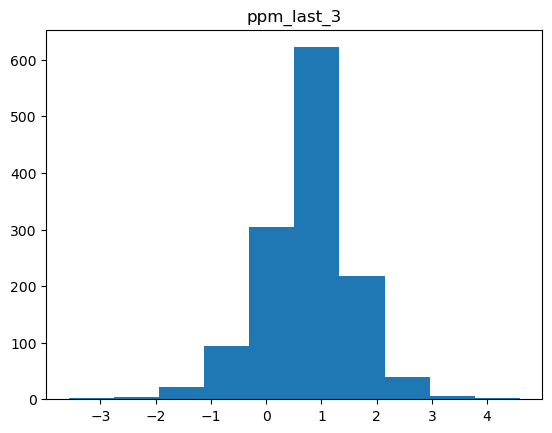

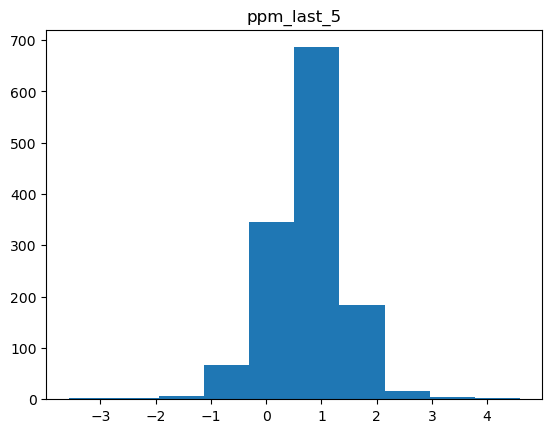

In [179]:
for col in numeric_types:
    plt.figure()
    plt.hist(hist[col])
    plt.title(col)
    plt.show()

#### Looks like all of the quantitative vars check out with no apparent outliers and are within expected ranges
#### Target Variable Points, looks very normal (yay!)

## EDA

#### Niave Baseline Model
- predicting mean values
- accuracy will be based on RMSE

In [180]:
hist['points'].skew()

np.float64(0.3280547762219114)

given the skew is roughly symmetric we will use mean for the niave model

In [181]:
mean_points = np.mean(hist["points"])
mean_points

np.float64(12.140898705255141)

In [182]:
target = "points"

X = hist.drop(columns=[target])
y = hist[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [183]:
baseline_pred = y_train.mean()

In [184]:
y_pred = np.repeat(baseline_pred, len(y_test))
med_pred = np.repeat(y_train.median, len(y_test))

In [185]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 12.357334781821473
Baseline RMSE: 16.07713333322969


every model from this point forward needs to be better than this or it is worse than niave and it is useless

#### Correlations

In [186]:
numeric_df = hist.select_dtypes(include=["number"])

In [187]:
corr_matrix = numeric_df.corr(method='pearson')

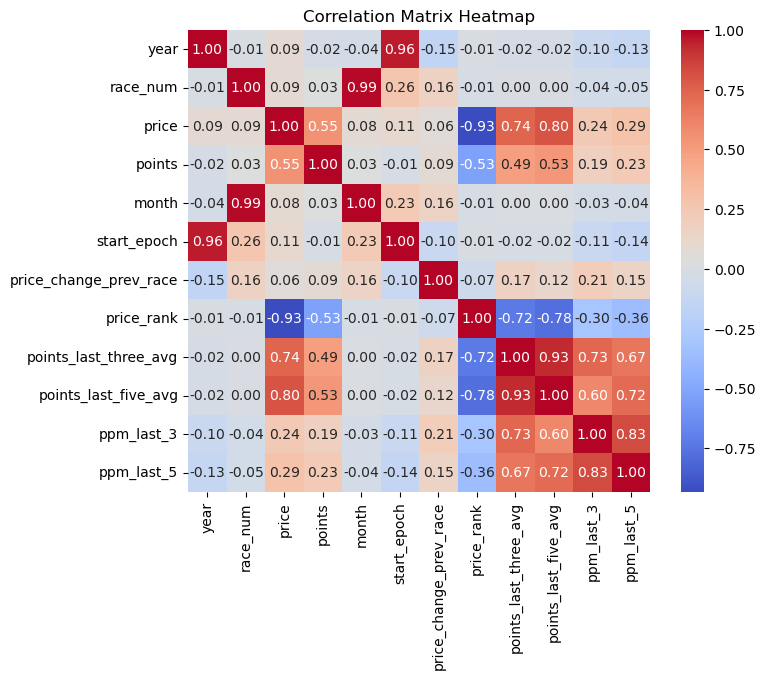

In [188]:
# Set up the Matplotlib figure
plt.figure(figsize=(8, 6))

# Create the Seaborn heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Add a title
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

Target Relationships
- price: .55 (higher price, higher points)
- points_last_three_avg: .49 (higher recent performance, more points)
- points_last_five_avg: .53 (higher recent performance, more points)
- ppm_last_3: .19 (higher recent performance, more points)
- ppm_last_5: .23 (higher recent performance, more points)
- price_rank: -.53 (lower rank, more points)

#### dropping cols with Multicollinearity
- month is highly correlated to race_num
- price_rank is essentially derived from price, so remove
- the running averages are also highly correlate , best to just keep the last 3 and 5 race averages. Will use create a momentum var that will take into account recent vs last 5 changes

## Marriage

In [189]:
married = pd.concat([hist, curr], ignore_index=True)

In [190]:
#ensure our years are right
married['year'].value_counts()

year
2024    469
2025    427
2023    417
2026     22
Name: count, dtype: int64

In [191]:
married["momentum"] = hist["points_last_three_avg"] - hist['points_last_five_avg']

In [192]:
married = married.drop(columns=["month", "price_rank", "points_last_three_avg", "ppm_last_3"])

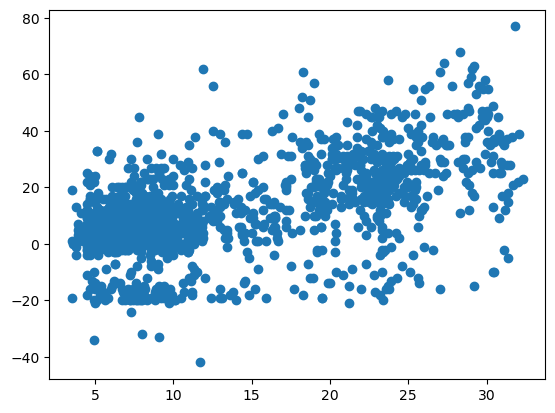

In [193]:
plt.scatter(hist["price"], hist["points"])

### Checking for Heteroscedasity


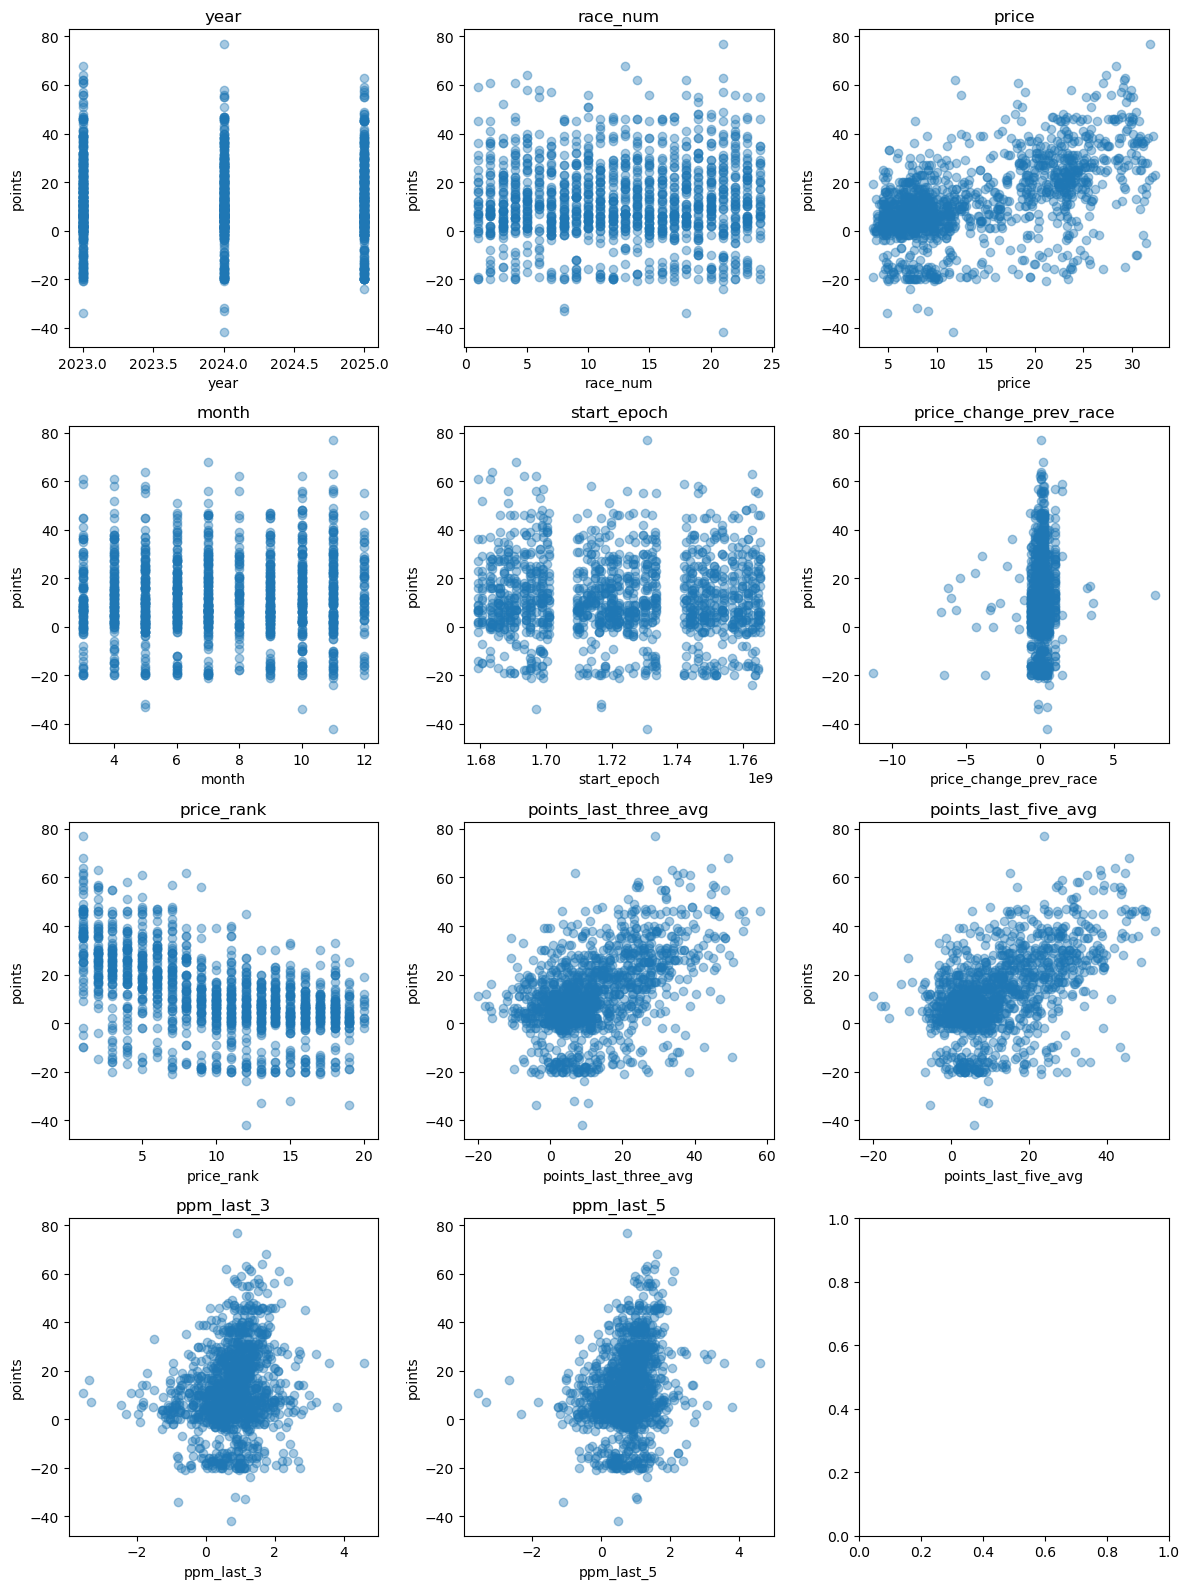

In [194]:
numeric_cols = hist.select_dtypes(include="number").columns.drop("points")

n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows*4))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.scatter(hist[col], hist["points"], alpha=0.4)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("points")

plt.tight_layout()
plt.show()

## Analysis of relationships with Points

- Strong Relationships: price, points_last_five_avg
- Moderate: ppm_last_5, race_num, momentum
- weak: price_change_prev_race

## Pre-processing


### Feature Engineering

#### Pricing

In [195]:
married['price_increase'] = (married['price_change_prev_race'] > 0).astype(int)
married['price_decrease'] = (married['price_change_prev_race'] < 0).astype(int)


#### Points

features that will allow us to see differences across drivers in the same car with the same constructor. These will act as a proxy for constructor performance

In [196]:
# proxy for constructor performance (car performance)

married["teammate_points_last5"] = (
    married.groupby(["constructor", "race_num"])["points_last_five_avg"]
    .transform(lambda x: x.sum() - x)
)

#driver strength independent of car strength (driver performance)
#positive means that the driver is outperforming teammate
#drivers outperforming their teammate tend to score more points

married["teammate_delta_last5"] = (
    married["points_last_five_avg"] - married["teammate_points_last5"]
)

##### FIXME in future

driver share of team performance (isolates driver dominance within a team)
measures how muhc of the team's perofrmance comes from that driver. Market share within the team

driver_share = (driver recent points) / (driver recent points + teammate recent points)

In [197]:
# need actual driver points and constructor points to build this feature

## Divorce

### Resplitting out Curr Week and Hist data prior to preprocessing

In [ ]:
def get_current_week_race_num():
    today_dt = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    #calendar load
    file_path = working_directory / "data" / "clean" / "race_session_meeting_info.csv"
    calendar = pd.read_csv(file_path).drop(columns=["Unnamed: 0"])

    #getting the current race number
    calendar["start_date"] = pd.to_datetime(calendar["start_date"], utc=True)
    next_race_int = calendar.loc[calendar["start_date"] >= today_dt, "race"].iloc[0].astype(int)

    #getting current year

    today_dt = pd.to_datetime(today_dt)
    year = today_dt.year


    return next_race_int, year


In [199]:
current_week_race_num, current_year = get_current_week_race_num()
print(f'Race: {current_week_race_num}, Year: {current_year}')

Race: 1, Year: 2026


In [200]:
curr = married[(married["race_num"] == current_week_race_num) & (married["year"] == current_year)]

In [201]:
key_cols = ["year", "race_num", "driver"]

hist = married.merge(
    curr[key_cols].drop_duplicates(),
    on=key_cols,
    how="left",
    indicator=True
)
hist = hist[hist["_merge"] == "left_only"].drop(columns="_merge")

In [202]:
hist.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'points', 'constructor', 'country_code', 'start_epoch',
       'price_change_prev_race', 'points_last_five_avg', 'ppm_last_5',
       'momentum', 'price_increase', 'price_decrease', 'teammate_points_last5',
       'teammate_delta_last5'],
      dtype='object')

### Pre Process Pipeline

In [203]:
hist = hist.sort_values(["start_epoch", "race_num"])
hist = hist.drop(columns=["start_epoch"])

In [204]:
from sklearn.model_selection import train_test_split #for splitting our data into train/test
from sklearn.compose import ColumnTransformer #allows for different preprocessing for different column groups
from sklearn.pipeline import Pipeline #chains steps in order (preprocess, model), prevents leakage
from sklearn.impute import SimpleImputer #fills in missing values in a consistent manner, we should have none
from sklearn.preprocessing import OneHotEncoder, StandardScaler #categories are (1/0) columns, standardizes numeric features
from sklearn.metrics import mean_absolute_error, mean_squared_error #metrics for our error


target = "points"
X = hist.drop(columns=[target])
y = hist[target]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #takes the median value and imputes as necesarry
    ("scaler", StandardScaler())  # keep for linear models; remove for tree models
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)





### Preprocess prediction set seperately
- this will be used after model development

In [205]:
#Standard Linear Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error

#RF Model
from sklearn.ensemble import RandomForestRegressor


### Train Test Split

In [206]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=201
)

### Declaring Model Types and Basic Params

In [207]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=201),
    "Lasso": Lasso(alpha=.01, max_iter=20000, random_state=201),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000, random_state=201),
    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=201, min_samples_leaf=5)
}

### Model Pipeline

In [208]:
y_train[y_train.isna()]

Series([], Name: points, dtype: float64)

In [209]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
tscv = TimeSeriesSplit(n_splits=5)

results = []
coef_tables = {}

for name, model in models.items():
    # Preprocessing for each model family
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipe,
        X,
        y,
        cv=tscv,
        scoring="neg_mean_absolute_error"
    )

    cv_mae = -cv_scores.mean()
    cv_mae_std = cv_scores.std()
    
    
    pipe.fit(X_train, y_train)
    

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)


    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append((name, cv_mae, cv_mae_std, train_mae, train_rmse, test_mae, test_rmse))

    # 3) Coefs for linear models only
    mdl = pipe.named_steps["model"]
    if hasattr(mdl, "coef_"):
        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        coefs = np.ravel(mdl.coef_)

        coef_tables[name] = (
            pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
        )

results_df = pd.DataFrame(
    results,
    columns=["model", "CV_MAE", "CV_MAE_STD", "Train_MAE", "Train_RMSE", "Test_MAE", "Test_RMSE"]
).sort_values("CV_MAE")

results_df

,model,CV_MAE,CV_MAE_STD,Train_MAE,Train_RMSE,Test_MAE,Test_RMSE
4,RandomForest,10.310315,0.931156,6.494902,9.229592,10.530513,14.305666
3,ElasticNet,11.004027,0.927128,9.209429,12.836496,10.401256,13.952938
1,Ridge,11.136924,0.982169,9.196870,12.789991,10.458685,13.946388
2,Lasso,11.179093,1.116922,9.198309,12.804396,10.420212,13.953123
0,Linear,12.935745,3.896697,9.196063,12.786300,10.487692,13.967594


- looks like RandomForest is overfitting the data, which is to be expected given the low dimensionality

## Coefficient Analysis

In [210]:
coef_tables = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    mdl = pipe.named_steps["model"]

    if hasattr(mdl, "coef_"):
        coefs = mdl.coef_.ravel()
        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

        coef_tables[name] = (
            pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
        )
    else:
        print(f"{name}: no coef_ (use feature_importances_ or permutation importance)")

RandomForest: no coef_ (use feature_importances_ or permutation importance)


In [211]:
coef_tables

{'Linear':                             feature      coef  abs_coef
 95             cat__constructor_MER  9.286362  9.286362
 86                  cat__driver_VER  9.066456  9.066456
 97             cat__constructor_RBR  8.813371  8.813371
 89             cat__constructor_ALP -8.722417  8.722417
 67                  cat__driver_DEV -7.331612  7.331612
 ..                              ...       ...       ...
 9        num__teammate_points_last5  0.148792  0.148792
 27  cat__race_name_Miami Grand Prix  0.132211  0.132211
 2                        num__price -0.097780  0.097780
 61                  cat__driver_ALO -0.005399  0.005399
 1                     num__race_num -0.003209  0.003209
 
 [121 rows x 3 columns],
 'Ridge':                               feature      coef  abs_coef
 86                    cat__driver_VER  8.313390  8.313390
 97               cat__constructor_RBR  7.771678  7.771678
 65                    cat__driver_BOT -7.020730  7.020730
 89               cat__constructor

In [212]:
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

search_spaces = {
    "Ridge": (
        Ridge(random_state=201),
        {"model__alpha": [0.01, 0.1, 1, 10, 100]}
    ),
    "Lasso": (
        Lasso(max_iter=20000, random_state=201),
        {"model__alpha": [0.0005, 0.001, 0.01, 0.1, 1]}
    ),
    "ElasticNet": (
        ElasticNet(max_iter=20000, random_state=201),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1],
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=201, n_jobs=-1),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3, 5]
        }
    )
}

tuning_results = []
best_pipes = {}

for name, (model, grid_params) in search_spaces.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grid=grid_params,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_pipes[name] = grid.best_estimator_
    cv_mae = -grid.best_score_

    test_pred = best_pipes[name].predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)

    tuning_results.append([name, cv_mae, test_mae, grid.best_params_])

pd.DataFrame(tuning_results, columns=["model", "best_cv_mae", "test_mae", "best_params"]).sort_values("best_cv_mae")

,model,best_cv_mae,test_mae,best_params
2,ElasticNet,9.708650,10.727127,"{'model__alpha': 1, 'model__l1_ratio': 0.9}"
1,Lasso,9.718913,10.743204,{'model__alpha': 1}
0,Ridge,9.727463,10.437649,{'model__alpha': 100}
3,RandomForest,9.881126,10.449611,"{'model__max_depth': 10, 'model__min_samples_l..."


Best Model:
model: ElasticNet
params: alpha: 1, model_l1_ratio: 0.9

In [213]:
import joblib
from pathlib import Path

out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

# if you used GridSearchCV:
best_pipe = grid.best_estimator_   # already fitted

joblib.dump(best_pipe, out_dir / "elasticnet_best_pipe.joblib")

['models/elasticnet_best_pipe.joblib']

In [214]:
import joblib
from pathlib import Path

out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

# if you used GridSearchCV:
best_pipe = grid.best_estimator_   # already fitted

joblib.dump(best_pipe, out_dir / "elasticnet_best_pipe.joblib")
import json

meta = {
    "model_name": "ElasticNet",
    "best_params": grid.best_params_,
    "cv_mae": float(-grid.best_score_),
    "features": list(X.columns),
}
with open("models/elasticnet_best_pipe_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

In [215]:
import joblib
import pandas as pd
import json

# 1) load fitted pipeline
best_pipe = joblib.load("models/elasticnet_best_pipe.joblib")

# (optional) load metadata so you know exactly what columns it expects
with open("models/elasticnet_best_pipe_meta.json", "r") as f:
    meta = json.load(f)

feature_cols = meta["features"]  # these are the raw columns from X.columns when you trained

In [216]:
current_week_df = curr.drop(columns=["points"])
current_week_df.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'constructor', 'country_code', 'start_epoch', 'price_change_prev_race',
       'points_last_five_avg', 'ppm_last_5', 'momentum', 'price_increase',
       'price_decrease', 'teammate_points_last5', 'teammate_delta_last5'],
      dtype='object')

In [217]:
X_curr = current_week_df.reindex(columns=feature_cols)


Seeing if any features are missing

In [218]:
missing = set(feature_cols) - set(current_week_df.columns)
print(missing)

set()


## Predicting Current Week Points

In [219]:
pred_points = best_pipe.predict(X_curr)

# 4) attach predictions
current_week_preds = current_week_df.copy()
current_week_preds["predicted_points"] = pred_points


In [231]:
output_predictons = current_week_preds[["year", "race_num", "driver", "price", "constructor", "predicted_points"]]
output_predictons


,year,race_num,driver,price,constructor,predicted_points
1313,2026,1,VER,27.7,RBR,38.163860
1314,2026,1,RUS,27.4,MER,24.508209
1315,2026,1,NOR,27.2,MCL,16.815132
1316,2026,1,PIA,25.5,MCL,16.833676
1317,2026,1,ANT,23.2,MER,20.579742
1318,2026,1,LEC,22.8,FER,21.135585
1319,2026,1,HAM,22.5,FER,18.805221
1320,2026,1,HAD,15.1,RBR,13.011118
1321,2026,1,GAS,12.0,ALP,4.257290
1322,2026,1,SAI,11.8,WIL,3.757901


In [232]:
output_predictons = output_predictons.reset_index(drop=True)

In [236]:
output_predictons.head()

,year,race_num,driver,price,constructor,predicted_points
0,2026,1,VER,27.7,RBR,38.163860
1,2026,1,RUS,27.4,MER,24.508209
2,2026,1,NOR,27.2,MCL,16.815132
3,2026,1,PIA,25.5,MCL,16.833676
4,2026,1,ANT,23.2,MER,20.579742


## Export predicted points


#### read in the driver predictions file


In [240]:
in_file_path = working_directory / "data" / "predictions" / "drivers" / f"driver_predictions_2026.csv"
hist_predictions = pd.read_csv(in_file_path)

#### append the current preds to the histrical predictions

In [238]:
new_hist_preds = pd.concat([output_predictons, hist_predictions],axis=0, ignore_index = True)

#### export the new file

In [239]:
file_path = working_directory / "data" / "predictions" / "drivers" / f"driver_predictions_2026.csv"

new_hist_preds.to_csv(file_path)
